# Ejercicio 1: Aprendizaje de la multiplicación de matrices 2×2


## 1. Planteamiento

En la Figura 6.1 del documento se contrastan dos enfoques para resolver un mismo problema:

- **Programación tradicional:** el programador conoce las reglas y las implementa de forma determinista.
- **Machine Learning:** no se programa la regla; se entrena un modelo con ejemplos (entradas y respuestas) para que aproxime la función.

Dadas dos matrices $A$ y $B$ de $2 \times 2$:

$$A = \begin{pmatrix} a_{11} & a_{12} \\ a_{21} & a_{22} \end{pmatrix}, \qquad B = \begin{pmatrix} b_{11} & b_{12} \\ b_{21} & b_{22} \end{pmatrix}$$

el producto analítico $C = A \times B$ está dado por

$$C = \begin{pmatrix} a_{11}b_{11} + a_{12}b_{21} & a_{11}b_{12} + a_{12}b_{22} \\ a_{21}b_{11} + a_{22}b_{21} & a_{21}b_{12} + a_{22}b_{22} \end{pmatrix}$$

## 2. Objetivos

1. Generar un dataset de **50.000 ejemplos** con enteros aleatorios entre $-20$ y $20$.
2. Entrenar dos modelos de regresión que aprendan la operación: una **red neuronal MLP** y una **regresión polinomial de grado 2**.
3. Probar ambos modelos con **10 ejemplos** y compararlos con la solución analítica.
4. Comparar el **costo computacional** (tiempo de inferencia y FLOPs) frente al método analítico.

## 3. Configuración y generación del dataset

In [1]:
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore", category=UserWarning)  # avisos de convergencia del MLP

# Parámetros del experimento
SEED = 42
N_SAMPLES = 50_000
MIN_VAL, MAX_VAL = -20, 20
N_TEST = 10

rng = np.random.default_rng(SEED)


def generar_dataset(n, rng):
    # Genera n pares (A, B) de enteros en [MIN_VAL, MAX_VAL] y su producto C = A @ B.
    # X: (n, 8) -> [a11 a12 a21 a22 b11 b12 b21 b22];  y: (n, 4) -> [c11 c12 c21 c22]
    A = rng.integers(MIN_VAL, MAX_VAL + 1, size=(n, 2, 2))
    B = rng.integers(MIN_VAL, MAX_VAL + 1, size=(n, 2, 2))
    C = np.matmul(A, B)                       # solución analítica exacta
    X = np.hstack([A.reshape(n, 4), B.reshape(n, 4)])
    y = C.reshape(n, 4)
    return X, y


X, y = generar_dataset(N_SAMPLES, rng)

# 49.990 ejemplos para entrenar y 10 reservados para la prueba final
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=N_TEST, random_state=SEED)

print("Dataset generado correctamente")
print(f" - Entradas de entrenamiento (X_train): {X_train.shape}")
print(f" - Salidas de entrenamiento  (y_train): {y_train.shape}")
print(f" - Ejemplos reservados para la prueba:  {X_test.shape[0]}")

Dataset generado correctamente
 - Entradas de entrenamiento (X_train): (49990, 8)
 - Salidas de entrenamiento  (y_train): (49990, 4)
 - Ejemplos reservados para la prueba:  10


## 4. Entrenamiento de los modelos

**Red neuronal MLP (8 → 128 → 64 → 4, ReLU).** Las entradas y las salidas se estandarizan antes de entrenar. Sin este paso, las salidas (que llegan hasta $\pm 800$) hacen que el entrenamiento converja muy mal. `TransformedTargetRegressor` aplica y revierte la estandarización de las salidas automáticamente.

**Regresión polinomial de grado 2.** Se expanden las 8 entradas a todos los monomios de grado $\le 2$ (45 términos, incluido el sesgo) y se ajusta una regresión lineal por mínimos cuadrados.

In [2]:
# --- Modelo 1: Perceptrón multicapa ---
mlp = TransformedTargetRegressor(
    regressor=make_pipeline(
        StandardScaler(),
        MLPRegressor(
            hidden_layer_sizes=(128, 64),
            activation="relu",
            learning_rate_init=1e-3,
            max_iter=200,
            tol=1e-6,
            n_iter_no_change=30,
            random_state=SEED,
        ),
    ),
    transformer=StandardScaler(),
)

print("Entrenando Modelo 1: MLP (puede tardar uno o dos minutos)...")
t0 = time.perf_counter()
mlp.fit(X_train, y_train)
t_train_mlp = time.perf_counter() - t0
print(f"  MLP entrenado en {t_train_mlp:.2f} s ({mlp.regressor_[-1].n_iter_} épocas)")

# --- Modelo 2: Regresión polinomial de grado 2 ---
poly_model = make_pipeline(PolynomialFeatures(degree=2, include_bias=True), LinearRegression())

print("Entrenando Modelo 2: Regresión polinomial de grado 2...")
t0 = time.perf_counter()
poly_model.fit(X_train, y_train)
t_train_poly = time.perf_counter() - t0
print(f"  Regresión polinomial entrenada en {t_train_poly:.4f} s")

Entrenando Modelo 1: MLP (puede tardar uno o dos minutos)...
  MLP entrenado en 183.64 s (200 épocas)
Entrenando Modelo 2: Regresión polinomial de grado 2...
  Regresión polinomial entrenada en 0.1984 s


## 5. Prueba con 10 ejemplos y comparación con la solución analítica

Las predicciones de los modelos son números reales; para compararlas con el resultado exacto (enteros) se redondean al entero más cercano. El error cuadrático medio (MSE) se calcula **antes** de redondear.

In [3]:
pred_mlp = mlp.predict(X_test)
pred_poly = poly_model.predict(X_test)

filas = []
for i in range(N_TEST):
    filas.append({
        "Ej.": i + 1,
        "A": X_test[i, :4].reshape(2, 2).tolist(),
        "B": X_test[i, 4:].reshape(2, 2).tolist(),
        "C analítico": y_test[i].reshape(2, 2).tolist(),
        "C MLP (redondeado)": np.round(pred_mlp[i]).astype(int).reshape(2, 2).tolist(),
        "C Polinomial (redondeado)": np.round(pred_poly[i]).astype(int).reshape(2, 2).tolist(),
        "MSE MLP": mean_squared_error(y_test[i], pred_mlp[i]),
        "MSE Polinomial": mean_squared_error(y_test[i], pred_poly[i]),
    })

df_resultados = pd.DataFrame(filas).set_index("Ej.")
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 200)
display(df_resultados.style.format({"MSE MLP": "{:.3f}", "MSE Polinomial": "{:.2e}"}))

aciertos_mlp = int((np.round(pred_mlp) == y_test).all(axis=1).sum())
aciertos_poly = int((np.round(pred_poly) == y_test).all(axis=1).sum())
print(f"\nMatrices C exactas tras redondear: MLP {aciertos_mlp}/{N_TEST} | Polinomial {aciertos_poly}/{N_TEST}")

,A,B,C analítico,C MLP (redondeado),C Polinomial (redondeado),MSE MLP,MSE Polinomial
Ej.,,,,,,,
1,"[[19, -9], [6, -1]]","[[-15, 7], [-20, -10]]","[[-105, 223], [-70, 52]]","[[-104, 216], [-71, 50]]","[[-105, 223], [-70, 52]]",13.264,1.34e-25
2,"[[10, 12], [-14, 0]]","[[13, -9], [-18, 13]]","[[-86, 66], [-182, 126]]","[[-90, 65], [-180, 128]]","[[-86, 66], [-182, 126]]",4.940,3.75e-26
3,"[[19, -2], [-8, -2]]","[[-8, -17], [-14, 1]]","[[-124, -325], [92, 134]]","[[-129, -326], [92, 142]]","[[-124, -325], [92, 134]]",22.047,1.22e-26
4,"[[20, -8], [-1, 5]]","[[-1, -20], [19, -18]]","[[-172, -256], [96, -70]]","[[-173, -250], [87, -73]]","[[-172, -256], [96, -70]]",33.789,1.62e-25
5,"[[17, 2], [14, -6]]","[[16, 6], [4, -13]]","[[280, 76], [200, 162]]","[[273, 76], [197, 156]]","[[280, 76], [200, 162]]",24.692,7.05e-26
6,"[[-5, 18], [-18, 2]]","[[-19, -14], [5, -20]]","[[185, -290], [352, 212]]","[[184, -295], [349, 208]]","[[185, -290], [352, 212]]",13.007,4.54e-26
7,"[[-1, -17], [1, -1]]","[[19, -4], [-12, 13]]","[[185, -217], [31, -17]]","[[184, -212], [28, -24]]","[[185, -217], [31, -17]]",20.402,9.99e-27
8,"[[-3, -11], [-20, 11]]","[[-6, -4], [-17, 10]]","[[205, -98], [-67, 190]]","[[203, -98], [-55, 183]]","[[205, -98], [-67, 190]]",52.382,8.30e-26
9,"[[-18, -6], [10, -10]]","[[-1, 19], [19, 4]]","[[-96, -366], [-200, 150]]","[[-99, -366], [-204, 146]]","[[-96, -366], [-200, 150]]",8.932,1.24e-26



Matrices C exactas tras redondear: MLP 0/10 | Polinomial 10/10


### Evaluación complementaria con un conjunto más grande

Diez ejemplos son pocos para sacar conclusiones fiables, por lo que se evalúan también ambos modelos con **10.000 pares nuevos** que no se usaron en el entrenamiento.

In [4]:
X_val, y_val = generar_dataset(10_000, rng)

metricas = []
for nombre, modelo in [("MLP (8-128-64-4)", mlp), ("Polinomial grado 2", poly_model)]:
    p = modelo.predict(X_val)
    metricas.append({
        "Modelo": nombre,
        "MSE": mean_squared_error(y_val, p),
        "MAE": mean_absolute_error(y_val, p),
        "Error máx. absoluto": np.abs(y_val - p).max(),
        "% matrices C exactas": 100 * (np.round(p) == y_val).all(axis=1).mean(),
    })

display(pd.DataFrame(metricas).set_index("Modelo").style.format({
    "MSE": "{:.3e}", "MAE": "{:.3e}", "Error máx. absoluto": "{:.3e}", "% matrices C exactas": "{:.2f}"
}))

,MSE,MAE,Error máx. absoluto,% matrices C exactas
Modelo,,,,
MLP (8-128-64-4),1.981e+01,3.487e+00,3.679e+01,0.01
Polinomial grado 2,1.014e-25,2.384e-13,1.791e-12,100.00


## 6. Análisis de costo computacional

Se comparan dos medidas:

1. **Costo teórico en FLOPs** por cada multiplicación de matrices (independiente del hardware). Se cuentan las multiplicaciones y sumas de las operaciones principales y se ignoran sesgos y activaciones, que aportan poco.
2. **Tiempo medido** de inferencia sobre 100.000 evaluaciones, tomando el mejor de 5 repeticiones para reducir el ruido.

,FLOPs por evaluación,Veces el costo analítico
Analítico (A @ B),12,1.0
MLP 8-128-64-4,"18,944","1,578.7"
Polinomial grado 2,396,33.0


TIEMPO DE INFERENCIA PARA 100.000 MULTIPLICACIONES
Analítico (np.matmul):      0.003361 s
MLP 8-128-64-4:             0.551647 s  (164x el analítico)
Polinomial grado 2:         0.122287 s  (36x el analítico)


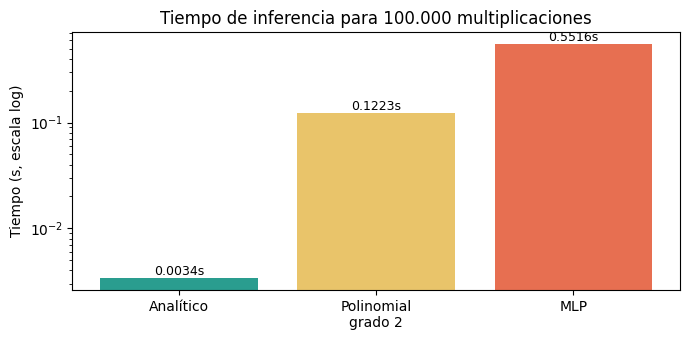

In [5]:
# ---------- 1) FLOPs teóricos por evaluación (1 MAC = 1 multiplicación + 1 suma = 2 FLOPs) ----------
flops_analitico = 8 + 4                                   # 8 multiplicaciones + 4 sumas

capas = [8, 128, 64, 4]
macs_mlp = sum(a * b for a, b in zip(capas[:-1], capas[1:]))   # 1024 + 8192 + 256
flops_mlp = 2 * macs_mlp

n_terminos = poly_model[0].n_output_features_             # 45 (incluye el sesgo)
n_prod_poly = n_terminos - 1 - 8                          # 36 productos para formar los monomios de grado 2
flops_poly = n_prod_poly + 2 * (n_terminos * 4)           # expansión + 4 salidas lineales

tabla_flops = pd.DataFrame({
    "FLOPs por evaluación": [flops_analitico, flops_mlp, flops_poly],
    "Veces el costo analítico": [1, flops_mlp / flops_analitico, flops_poly / flops_analitico],
}, index=["Analítico (A @ B)", "MLP 8-128-64-4", "Polinomial grado 2"])
display(tabla_flops.style.format({"FLOPs por evaluación": "{:,.0f}", "Veces el costo analítico": "{:,.1f}"}))

# ---------- 2) Tiempo de inferencia medido ----------
N_BENCH = 100_000
X_bench, _ = generar_dataset(N_BENCH, rng)
A_bench = X_bench[:, :4].reshape(-1, 2, 2)
B_bench = X_bench[:, 4:].reshape(-1, 2, 2)


def mejor_tiempo(f, repeticiones=5):
    tiempos = []
    for _ in range(repeticiones):
        t0 = time.perf_counter()
        f()
        tiempos.append(time.perf_counter() - t0)
    return min(tiempos)


t_analitico = mejor_tiempo(lambda: np.matmul(A_bench, B_bench))
t_mlp = mejor_tiempo(lambda: mlp.predict(X_bench))
t_poly = mejor_tiempo(lambda: poly_model.predict(X_bench))

print("=" * 66)
print(f"TIEMPO DE INFERENCIA PARA {N_BENCH:,} MULTIPLICACIONES".replace(",", "."))
print("=" * 66)
print(f"Analítico (np.matmul):      {t_analitico:.6f} s")
print(f"MLP 8-128-64-4:             {t_mlp:.6f} s  ({t_mlp / t_analitico:,.0f}x el analítico)")
print(f"Polinomial grado 2:         {t_poly:.6f} s  ({t_poly / t_analitico:,.0f}x el analítico)")

fig, ax = plt.subplots(figsize=(7, 3.5))
nombres = ["Analítico", "Polinomial\ngrado 2", "MLP"]
tiempos = [t_analitico, t_poly, t_mlp]
barras = ax.bar(nombres, tiempos, color=["#2a9d8f", "#e9c46a", "#e76f51"])
ax.set_yscale("log")
ax.set_ylabel("Tiempo (s, escala log)")
ax.set_title(f"Tiempo de inferencia para {N_BENCH:,} multiplicaciones".replace(",", "."))
for b, t in zip(barras, tiempos):
    ax.text(b.get_x() + b.get_width() / 2, t, f"{t:.4f}s", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

## 7. Conclusiones

**Exactitud**

- La **regresión polinomial de grado 2** reproduce la operación de forma exacta (MSE del orden de $10^{-25}$, es decir, solo error de redondeo de punto flotante). Es esperable: cada elemento $c_{ij} = a_{i1}b_{1j} + a_{i2}b_{2j}$ es una combinación lineal de productos de dos entradas, que es justo lo que representa la base de monomios de grado 2. El modelo contiene a la función verdadera, así que el entrenamiento solo tiene que *recuperar* los coeficientes.
- La **red MLP** solo aproxima la función. Aun con entradas y salidas estandarizadas, su error es varios órdenes de magnitud mayor y casi nunca acierta las cuatro entradas de $C$ tras redondear. Aprender un producto de dos variables con activaciones ReLU es costoso, porque hay que construirlo con tramos lineales, y el resultado no es exacto.

**Costo computacional**

- Analítico: **12 FLOPs** por multiplicación (8 productos y 4 sumas), complejidad $O(1)$.
- MLP: $1024 + 8192 + 256 = 9472$ MACs, es decir, **18.944 FLOPs**, unas **1.580 veces** el costo analítico, además de necesitar entrenamiento.
- Polinomial de grado 2: unos **400 FLOPs**, unas 33 veces el costo analítico.
- El tiempo medido refleja el mismo orden (analítico < polinomial < MLP), pero las razones son menores que las de FLOPs, porque las multiplicaciones matriciales del MLP aprovechan bien las librerías optimizadas (BLAS) y `np.matmul` sobre matrices diminutas está dominado por el costo fijo de la llamada. Las razones exactas dependen del hardware.

**Idea principal.** Cuando existe una regla exacta y conocida, como la multiplicación de matrices, programarla es más exacto, más barato y no necesita datos. El Machine Learning se justifica cuando **no** se conoce o no es práctico escribir la regla (filtrado de spam, visión por computador, etc.). El éxito de la regresión polinomial aquí no contradice esto: funciona porque se le dio una familia de funciones que ya contenía la solución, es decir, se incorporó conocimiento del problema.